In [1]:

!pip install qiskit qiskit-aer

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# Quantum simulator
simulator = AerSimulator()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 100.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.1 MB/s eta 0:00:00



----- EASY CHALLENGE -----
   Shots  0 Count  1 Count  Probability P(0)
0    100       48       52             0.480
1   1000      501      499             0.501
2  10000     5020     4980             0.502


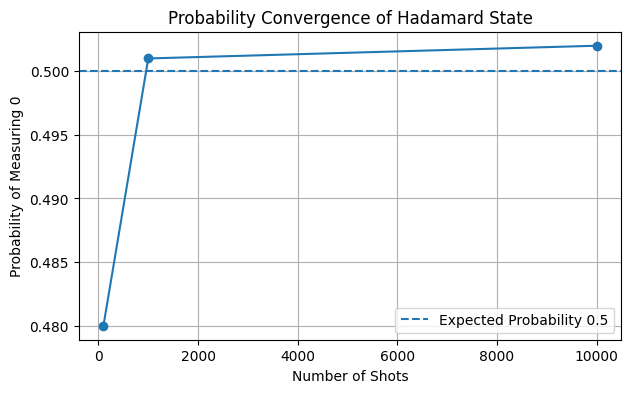

In [2]:
def measure_hadamard(shots):

    qc = QuantumCircuit(1, 1)

    # Create |+> state
    qc.h(0)

    # Measure
    qc.measure(0, 0)

    compiled = transpile(qc, simulator)

    result = simulator.run(
        compiled,
        shots=shots
    ).result()

    return result.get_counts()


print("\n----- EASY CHALLENGE -----")

shot_values = [100, 1000, 10000]

easy_results = []


for shots in shot_values:

    counts = measure_hadamard(shots)

    probability_zero = counts.get("0", 0) / shots

    easy_results.append({
        "Shots": shots,
        "0 Count": counts.get("0", 0),
        "1 Count": counts.get("1", 0),
        "Probability P(0)": probability_zero
    })


easy_table = pd.DataFrame(easy_results)

print(easy_table)


# Plot convergence

plt.figure(figsize=(7,4))

plt.plot(
    easy_table["Shots"],
    easy_table["Probability P(0)"],
    marker="o"
)

plt.axhline(
    y=0.5,
    linestyle="--",
    label="Expected Probability 0.5"
)

plt.xlabel("Number of Shots")
plt.ylabel("Probability of Measuring 0")

plt.title(
    "Probability Convergence of Hadamard State"
)

plt.legend()
plt.grid()

plt.show()

In [3]:
print("\n----- MEDIUM CHALLENGE -----")


# |+> State

plus = QuantumCircuit(1,1)

plus.h(0)     # create |+>
plus.h(0)     # X basis measurement

plus.measure(0,0)


result_plus = simulator.run(
    transpile(plus, simulator),
    shots=1000
).result()


plus_counts = result_plus.get_counts()


print("\nMeasurement of |+> in X basis:")
print(plus_counts)



# |-> State

minus = QuantumCircuit(1,1)

minus.x(0)
minus.h(0)

# X basis measurement
minus.h(0)

minus.measure(0,0)


result_minus = simulator.run(
    transpile(minus, simulator),
    shots=1000
).result()


minus_counts = result_minus.get_counts()


print("\nMeasurement of |-> in X basis:")
print(minus_counts)


----- MEDIUM CHALLENGE -----

Measurement of |+> in X basis:
{'0': 1000}

Measurement of |-> in X basis:
{'1': 1000}



----- HARD CHALLENGE -----

Bell Pair Measurement:
{'00': 502, '11': 498}


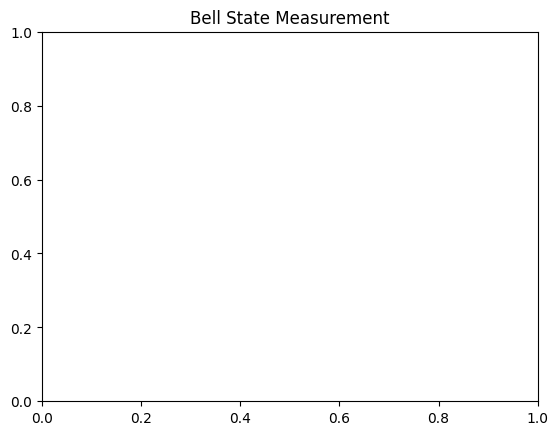

In [4]:
print("\n----- HARD CHALLENGE -----")


bell = QuantumCircuit(2,2)


# Create Bell State
bell.h(0)

bell.cx(0,1)


# Measure both qubits
bell.measure([0,1],[0,1])


bell_result = simulator.run(
    transpile(bell, simulator),
    shots=1000
).result()


bell_counts = bell_result.get_counts()


print("\nBell Pair Measurement:")
print(bell_counts)


plot_histogram(
    bell_counts
)

plt.title(
    "Bell State Measurement"
)

plt.show()

In [5]:
print("\n----- ROTATION ANGLE ESTIMATION -----")


# Unknown rotation

actual_theta = np.pi/3


rotation = QuantumCircuit(1,1)


rotation.ry(
    actual_theta,
    0
)


rotation.measure(
    0,
    0
)


rotation_result = simulator.run(
    transpile(rotation, simulator),
    shots=10000
).result()


rotation_counts = rotation_result.get_counts()


print(
    "Measurement Results:",
    rotation_counts
)



# Estimate angle

probability_one = (
    rotation_counts.get("1",0)
    /
    10000
)


estimated_theta = (
    2 *
    np.arcsin(
        np.sqrt(probability_one)
    )
)


print(
    "Probability of measuring 1:",
    probability_one
)

print(
    "Estimated Rotation Angle:",
    estimated_theta
)

print(
    "Actual Rotation Angle:",
    actual_theta
)



----- ROTATION ANGLE ESTIMATION -----
Measurement Results: {'1': 2525, '0': 7475}
Probability of measuring 1: 0.2525
Estimated Rotation Angle: 1.0529614951625172
Actual Rotation Angle: 1.0471975511965976


In [6]:
# =====================================================
# Reflection Answers
# =====================================================


print("\n----- REFLECTION -----")

print("""
1. Increasing the number of shots improves probability estimation because
more samples reduce statistical fluctuations. According to the law of
large numbers, measurement results approach the true quantum probability.

2. True quantum randomness is useful in cryptography, secure communication,
random number generation, scientific simulations, and fair lottery systems.
""")


----- REFLECTION -----

1. Increasing the number of shots improves probability estimation because
more samples reduce statistical fluctuations. According to the law of
large numbers, measurement results approach the true quantum probability.

2. True quantum randomness is useful in cryptography, secure communication,
random number generation, scientific simulations, and fair lottery systems.

